1. Data Processing Progress

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

In [34]:
df = pd.read_csv('/Users/rayxu/Downloads/tmpdworw0d4.csv')
print(df.columns)
df.describe()

Index(['case_id', 'open_date', 'case_topic', 'service_name',
       'assigned_department', 'assigned_team', 'case_status', 'closure_reason',
       'closure_comments', 'close_date', 'target_close_date', 'on_time',
       'report_source', 'full_address', 'street_number', 'street_name',
       'zip_code', 'neighborhood', 'public_works_district',
       'city_council_district', 'fire_district', 'police_district', 'ward',
       'precinct', 'submitted_photo', 'closed_photo', 'longitude', 'latitude'],
      dtype='object')


,zip_code,city_council_district,fire_district,ward,precinct,submitted_photo,closed_photo,longitude,latitude
count,5052.000000,5106.000000,5106.000000,5075.000000,5075.000000,0.0,0.0,5051.000000,5051.000000
mean,2127.605305,4.537799,6.813944,11.122562,7.302857,NaN,NaN,-71.085467,42.324886
std,23.105420,2.563329,3.207339,6.857951,4.748908,NaN,NaN,0.035173,0.034433
min,2108.000000,0.000000,0.000000,1.000000,1.000000,NaN,NaN,-71.181032,42.233076
25%,2118.000000,2.000000,4.000000,5.000000,3.000000,NaN,NaN,-71.108655,42.294456
50%,2125.000000,4.000000,7.000000,11.000000,7.000000,NaN,NaN,-71.075110,42.332301
75%,2130.000000,7.000000,9.000000,18.000000,10.000000,NaN,NaN,-71.061990,42.351264
max,2467.000000,9.000000,12.000000,22.000000,23.000000,NaN,NaN,-70.997868,42.392547


In [35]:
# Formatting Date and Time
df['open_date'] = pd.to_datetime(df['open_date'], errors='coerce', utc=True)
df['close_date'] = pd.to_datetime(df['close_date'], errors='coerce', utc=True)

# Handling “Open” work orders with right-censored data
current_time = pd.Timestamp('2026-03-01', tz='UTC')

# Create a new indicator column: 1 = Not yet resolved (Censored), 0 = Closed
df['is_censored'] = np.where(df['case_status'] == 'In progress', 1, 0)

# Calculate the target variable: Resolution Time (in days) If Closed, the time difference is close - open; if Open, the time difference is current_time - open
df['resolution_time_days'] = np.where(
    df['case_status'] == 'Closed',
    (df['close_date'] - df['open_date']).dt.total_seconds() / (24 * 3600),
    (current_time - df['open_date']).dt.total_seconds() / (24 * 3600)
)

# Filter out “test orders” or invalid negative orders that are closed just a few minutes after being placed
df = df[df['resolution_time_days'] >= 0]

# Generate Baseline classification label: Is this a long-tail delay (> 30 days)?
df['is_overdue'] = np.where(df['resolution_time_days'] > 30, 1, 0)

# Zipcode filter
df['zip_code'] = df['zip_code'].fillna(0).astype(int).astype(str).str.zfill(5)
# setting 00000 as NaN for better handling of missing zip codes
df['zip_code'] = df['zip_code'].replace('00000', np.nan)

# primary outcome
print(f"Total valid records: {len(df)}")
print(f"Percentage of Overdue tickets (>30 days): {df['is_overdue'].mean():.2%}")
print("\nSample of calculated targets:")
print(df[['case_status', 'is_censored', 'resolution_time_days', 'is_overdue']].head(10))

Total valid records: 5096
Percentage of Overdue tickets (>30 days): 29.26%

Sample of calculated targets:
   case_status  is_censored  resolution_time_days  is_overdue
0       Closed            0              0.097390           0
1  In progress            1             47.215683           1
2  In progress            1             51.243763           1
3       Closed            0              0.112556           0
4       Closed            0              0.331955           0
5       Closed            0              0.179500           0
6       Closed            0              0.131493           0
7       Closed            0              7.158642           0
8       Closed            0              2.771595           0
9  In progress            1            128.504710           1


#### If we simply delete open tickets with a `close_date` of `NaN`, we would be unable to identify the true “long-forgotten appeals from vulnerable groups.” Therefore, I attempted to apply the concept of right-censoring from survival analysis, using the data retrieval date as the current censoring point to reconstruct the actual waiting times for these long-tail outliers.

2. Preliminary Data Visualizations (311 Public Services)

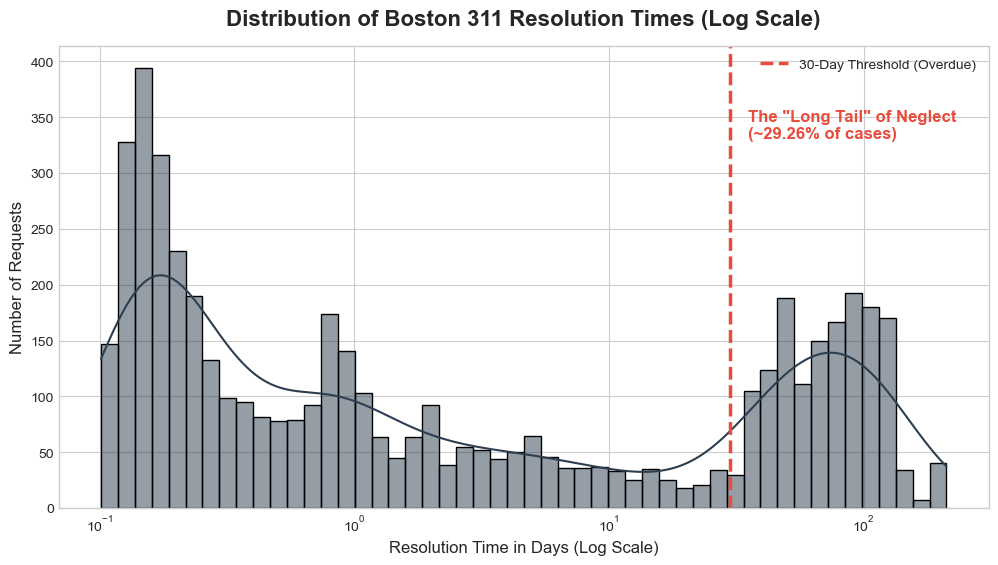

Overdue cases percentage: 29.26%


In [43]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'

def plot_resolution_time_distribution(df):
    """
    Plots the distribution of resolution times and returns the percentage of overdue cases.
    
    Parameters:
        df (pd.DataFrame): DataFrame containing 'resolution_time_days' and 'is_overdue' columns.
    
    Returns:
        float: Percentage of overdue cases.
    """
    plt.style.use('seaborn-v0_8-whitegrid')
    plt.rcParams['font.family'] = 'sans-serif'

    fig, ax = plt.subplots(figsize=(12, 6))
    # Log-scale Histogram with KDE For a tuple with a duration of 0, add 0.1 to prevent a log(0) error.
    sns.histplot(df['resolution_time_days'] + 0.1, 
                 bins=50, 
                 log_scale=True, 
                 kde=True, 
                 color='#2c3e50',
                 ax=ax)
    # Mark 30-day extreme delay
    ax.axvline(30, color='#e74c3c', linestyle='--', linewidth=2.5, label='30-Day Threshold (Overdue)')
    
    # Calculate the percentage of overdue cases
    overdue_percentage = df["is_overdue"].mean()
    
    # Add text annotation with the calculated percentage
    ax.text(35, ax.get_ylim()[1]*0.8, f'The "Long Tail" of Neglect\n(~{overdue_percentage:.2%} of cases)', 
            color='#e74c3c', fontsize=12, fontweight='bold')

    ax.set_title('Distribution of Boston 311 Resolution Times (Log Scale)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Resolution Time in Days (Log Scale)', fontsize=12)
    ax.set_ylabel('Number of Requests', fontsize=12)
    ax.legend()
    
    # Show the plot
    bbox_inches='tight'
    plt.savefig(f'{export_dir}/ticket_distribution_plot.png', bbox_inches='tight', dpi=300)
    plt.show()
    
    # Return the overdue percentage
    return overdue_percentage
overdue_percentage = plot_resolution_time_distribution(df)
print(f"Overdue cases percentage: {overdue_percentage:.2%}")

# 3. Modeling Methods
## Methodological Refinements & Roadmap
In transitioning from a feasible way, we applied several critical engineering constraints to our roadmap:

* **De-prioritized: Time-Series Structural Break (COVID-19)**
  * *Rationale:* Introducing longitudinal structural breaks at this stage injects severe time-series noise. Our primary mandate is auditing **Spatial Equity**; controlling for geographic confounders is our MVP priority. Temporal shifts will be addressed in next phase.
* **Rejected: k-NN Imputation for Census Data**
  * *Rationale:* Imputing missing `zip_code` or SVI metrics via k-NN risks fabricating critical demographic data (an "Ecological Fallacy" risk). 
  * *Resolution in Next Phase:* Missing geo-tags are resolved via Lat/Lon reverse geocoding; residual missing SVI regions (e.g., purely commercial zones) are explicitly dropped to preserve statistical integrity.
* **Refined: k-Means Clustering Strategy**
  * *Rationale:* Clustering 175+ request types using basic categorical text yields low business value.
  * *Resolution:* We will cluster based on extracted **Operational Metrics** `[Volume, Mean Resolution Time, Variance, Overdue Rate]`. This groups tickets into actionable archetypes (e.g., "High-Frequency/Fast-Response" vs. "Systemic-Delay").
* **Pivoted: SVD Text Mining for "Dismissal Index"**
  * *Rationale:* The `case_description` field is often uninformative or missing.
  * *Resolution:* We identified the `closure_comments` field as a high-value target. We will apply TF-IDF and SVD to extract latent topics (e.g., "Investigated - No Issue", "Duplicate"). This allows us to engineer a "Dismissal Index"—quantifying if vulnerable neighborhoods face higher rates of arbitrary ticket closures.

In [37]:
svi_df = pd.read_csv('/Users/rayxu/Downloads/SVI_2022_US_ZCTA.csv')

# Convert the Zipcode string to a standardized 5-digit format (with leading zeros if necessary)
svi_df['zip_code'] = svi_df['FIPS'].astype(str).str.zfill(5)

# replace -999.0 with NaN for better handling of missing values in SVI features
svi_df = svi_df.replace(-999.0, np.nan)

# feature selection: Only focus on the 7 core SVI features that are most relevant to social vulnerability and likely to impact service delivery.
# EP_: Estimated Percentage，
svi_features = [
    'zip_code',
    'EP_POV150',  # poverty (<150% of federal poverty level)
    'EP_UNEMP',   # unemployment
    'EP_NOHSDP',  # non high school diploma
    'EP_LIMENG',  # limited English proficiency
    'EP_MINRTY',  # minority population
    'EP_NOVEH'    # no vehicle
]

svi_clean = svi_df[svi_features].copy()

# Merge the SVI features back to our main DataFrame based on zip_code
df_model = pd.merge(df, svi_clean, on='zip_code', how='inner')
print(f"Data shape after merge: {df_model.shape}")
print("\nCheck for hidden nulls in SVI features:")
print(df_model[svi_features].isnull().sum())

print("\nSample of final Modeling Data:")
display(df_model[['case_status', 'zip_code', 'is_overdue', 'EP_LIMENG', 'EP_POV150']].head())

Data shape after merge: (5042, 37)

Check for hidden nulls in SVI features:
zip_code     0
EP_POV150    0
EP_UNEMP     0
EP_NOHSDP    0
EP_LIMENG    0
EP_MINRTY    0
EP_NOVEH     0
dtype: int64

Sample of final Modeling Data:


,case_status,zip_code,is_overdue,EP_LIMENG,EP_POV150
0,Closed,02124,0,10.1,27.2
1,In progress,02129,1,4.2,13.6
2,In progress,02128,1,23.9,23.9
3,Closed,02109,0,1.8,8.1
4,Closed,02130,0,4.4,17.5


In [38]:
#Starting Baseline Logistic Regression (Statsmodels)
df_reg = df_model.copy()
# remove rows with missing values in SVI features or target variable & filter out "Noted" cases that are not truly closed
if 'closure_reason' in df_reg.columns:
    df_reg = df_reg[df_reg['closure_reason'] != 'Noted']
svi_features = ['EP_POV150', 'EP_UNEMP', 'EP_NOHSDP', 'EP_LIMENG', 'EP_MINRTY', 'EP_NOVEH']
# encoding categorical variables
category_col = 'service_name' 
source_col = 'report_source'
#drop rows with missing values in SVI features or target variable
df_reg = df_reg.dropna(subset=svi_features + ['is_overdue', category_col, source_col])

#Dimension Reduction of Business and Channel Characteristics
# top 15 most common services, the rest are grouped into "Other Services"
top_15_services = df_reg[category_col].value_counts().nlargest(15).index
df_reg['service_group'] = np.where(df_reg[category_col].isin(top_15_services), df_reg[category_col], 'Other_Services')
# top 5 most common sources, the rest are grouped into "Other Sources"
top_5_sources = df_reg[source_col].value_counts().nlargest(5).index
df_reg['source_group'] = np.where(df_reg[source_col].isin(top_5_sources), df_reg[source_col], 'Other_Sources')

#Constructing a matrix of dummy variables
#drop_first=True avoids multicollinearity by dropping the first category in each group
service_dummies = pd.get_dummies(df_reg['service_group'], prefix='Serv', drop_first=True)
source_dummies = pd.get_dummies(df_reg['source_group'], prefix='Src', drop_first=True)

X = pd.concat([df_reg[svi_features], service_dummies, source_dummies], axis=1)
X = sm.add_constant(X) # add constant term for intercept
y = df_reg['is_overdue']
# ensure all features are numeric
X = X.astype(float)
y = y.astype(float)

print(f"Final Model Dimensions: {X.shape}")
try:
    logit_res = sm.Logit(y, X).fit(maxiter=100, method='newton')
    print(logit_res.summary())
    
    #  Odds Ratio
    params = logit_res.params
    conf = logit_res.conf_int()
    conf['Odds Ratio'] = params
    conf = np.exp(conf) 
    print("\nOdds Ratios (Impact Strength)")
    print(conf.loc[svi_features])
    impact_pct = (conf['Odds Ratio'] - 1) * 100
    for feature in svi_features:
        print(f"{feature}: Increased risk of delinquency by  {impact_pct[feature]:.2f}% (for every 1% increase in this vulnerability)")
except Exception as e:
    print(f"Model failed: {e}")
    

Final Model Dimensions: (4644, 18)
         Current function value: 0.422013
         Iterations: 100
                           Logit Regression Results                           
Dep. Variable:             is_overdue   No. Observations:                 4644
Model:                          Logit   Df Residuals:                     4626
Method:                           MLE   Df Model:                           17
Date:                Mon, 23 Mar 2026   Pseudo R-squ.:                  0.3218
Time:                        05:17:00   Log-Likelihood:                -1959.8
converged:                      False   LL-Null:                       -2889.6
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -1.4949      0.187     -8.000      0.000

/Applications/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Applications/anaconda3/lib/python3.12/site-packages/pandas/core/internals/blocks.py:393: RuntimeWarning: overflow encountered in exp
  result = func(self.values, **kwargs)


In [39]:
# Apply K-Means Clustering to Identify Operationally Similar Service Categories
#Operational Metrics K-Means Clustering
ops_metrics = df.groupby(category_col).agg(
    Volume=('is_overdue', 'count'),  # total number of requests in this category
    Mean_Res_Time=('resolution_time_days', 'mean'), # average resolution time
    Time_Variance=('resolution_time_days', 'var'),  # variance of resolution time (instability)
    Overdue_Rate=('is_overdue', 'mean') # rate of overdue cases
).fillna(0)

# filter out categories with very low volume to avoid noise in clustering
ops_metrics = ops_metrics[ops_metrics['Volume'] >= 10]
# log-transform the metrics to reduce skewness
ops_metrics['Log_Volume'] = np.log1p(ops_metrics['Volume'])
features_to_cluster = ['Log_Volume', 'Mean_Res_Time', 'Time_Variance', 'Overdue_Rate']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(ops_metrics[features_to_cluster])

# Using the Elbow Method to determine optimal number of clusters
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
ops_metrics['Cluster'] = kmeans.fit_predict(X_scaled)
cluster_summary = ops_metrics.groupby('Cluster')[['Volume', 'Mean_Res_Time', 'Time_Variance', 'Overdue_Rate']].mean()
print(cluster_summary.round(2))
for i in range(4):
    sample_services = ops_metrics[ops_metrics['Cluster'] == i].sort_values('Volume', ascending=False).head(3).index.tolist()
    print(f"Cluster {i} A typical example: {sample_services}")
# Mapping Dictionary)
archetype_dict = {
    3: "Quick Hits ",
    0: "High-Volume Routine ",
    1: "Structural Backlog ",
    2: "The Black Hole "
}
ops_metrics['Archetype'] = ops_metrics['Cluster'].map(archetype_dict)
print(ops_metrics[['Archetype', 'Volume', 'Overdue_Rate']].sample(5))
#Merge back into the original table
df['Archetype'] = df[category_col].map(ops_metrics['Archetype']).fillna('Rare / Unclassified')
print(df['Archetype'].value_counts(dropna=False))

          Volume  Mean_Res_Time  Time_Variance  Overdue_Rate
Cluster                                                     
0         577.67          54.10        1758.47          0.67
1        1118.50          10.48        1224.67          0.09
2         519.00           1.45          59.20          0.02
3         150.25          19.58        1285.82          0.22
Cluster 0 A typical example: ['Street Light Outage', 'Street Light Other', 'Planting Request']
Cluster 1 A typical example: ['Domestic Animal Issue', 'Wild Animal Issue']
Cluster 2 A typical example: ['Fallen Tree or Branches']
Cluster 3 A typical example: ['Pruning Request', 'Street Light Knockdown', 'Lost Pet']
                                    Archetype  Volume  Overdue_Rate
service_name                                                       
Street Light Knockdown            Quick Hits      161      0.217391
Wild Animal Issue         Structural Backlog      730      0.071233
Fallen Tree or Branches       The Black Hole   

In [40]:
# SVD Text Mining on Closure Comments

# focus on the 'closure_comments' field, which contains unstructured text data 
text_df = df.dropna(subset=['closure_comments']).copy()
print(f"Valid comments to analyze: {len(text_df)}")
# Use TF-IDF to convert texts
max_df=0.8 # ignore terms that appear in more than 80% of documents (too common)
tfidf = TfidfVectorizer(stop_words='english', max_features=1000, max_df=0.9, min_df=10)
X_tfidf = tfidf.fit_transform(text_df['closure_comments'].astype(str))

#Latent Semantic Analysis
n_topics = 5
svd = TruncatedSVD(n_components=n_topics, random_state=42)
X_svd = svd.fit_transform(X_tfidf)

# Print top terms for each topic
terms = tfidf.get_feature_names_out()
for i, comp in enumerate(svd.components_):
    top_terms_idx = comp.argsort()[:-9:-1] #Retrieve the top 8 words with the highest weights
    top_terms = [terms[idx] for idx in top_terms_idx]
    print(f"Topic {i}: {', '.join(top_terms)}")


Valid comments to analyze: 1006
Topic 0: removed, tree, gr, jb, jl, private, city, od
Topic 1: duplicate, bcs, request, case, existing, number, tree, inspected
Topic 2: tree, private, property, trees, boston, maintain, new, pruned
Topic 3: private, property, jl, city, maintain, fell, trees, gr
Topic 4: repaired, working, replaced, light, lights, fixture, installed, private


## Phase 2 Roadmap: From Baseline to Advanced Equity Audit
With the baseline logistic regression confirming the presence of spatial inequity (e.g., higher overdue risks in Limited English communities), our next phase will shift from *identifying* the gap to *diagnosing the mechanisms* behind it. 
Based on our preliminary advanced analytics, our April deliverables will focus on:

### 1. Operationalizing Business Archetypes (K-Means Integration)
Instead of controlling for 175+ noisy request types, we have successfully clustered the operations into 4 core archetypes: `Quick Hits`, `High-Volume Routine`, `Structural Backlog`, and `The Black Hole`. 
* **Next Step:** We will use these archetypes as definitive control variables to isolate true discriminatory neglect from structural engineering bottlenecks. We will specifically audit which neighborhoods suffer most from the "Black Hole" cases (150+ days overdue).

### 2. The "Dismissal Index" via NLP (SVD)
Our preliminary SVD analysis on `closure_comments` revealed latent topics heavily associated with administrative pushback (e.g., "Duplicate", "Noted", "Transitioned to BPD/BWSC").
* **Next Step:** We will engineer a "Dismissal Index" using the topic weights from our SVD. We will test a new hypothesis: *Do highly vulnerable communities (High SVI) experience statistically higher rates of arbitrary ticket closures compared to affluent areas?*
### 3. Geospatial Visualization (The Final Deliverable)
* **Next Step:** Overlaying our predictive risk models and the "Dismissal Index" onto Boston's SVI shapefiles (GeoPandas) to create an interactive, equity-focused audit map for municipal stakeholders.

**Conclusion for March Check-in:** The MVP model is robust, the statistical baseline is significant, and the feature engineering for Phase 2 is already successfully prototyped.

In [42]:
import os
export_dir = '../others/exports'
os.makedirs(export_dir, exist_ok=True)

# save the resolution time distribution plot
plt.savefig(f'{export_dir}/ticket_distribution_plot.png', bbox_inches='tight', dpi=300)
# save the logistic regression summary
with open(f'{export_dir}/logistic_regression_summary.txt', 'w') as f:
    f.write(logit_res.summary().as_text())

# save the odds ratios table and cluster summary as CSV files
conf.loc[svi_features].to_csv(f'{export_dir}/odds_ratios.csv')
cluster_summary.to_csv(f'{export_dir}/kmeans_cluster_summary.csv')


<Figure size 640x480 with 0 Axes>